# Parse Race Prediction Metrics Notebook

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
paths = [
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20240403_20240712_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20240712_20241020_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20241020_20250128_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20250128_20250508_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20250508_20250816_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20250816_20251124_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20251124_20260304_48001360.json',
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics/RunRacePredictions_20260304_20260612_48001360.json'
]

race_predictions_df = pd.DataFrame()

for path in paths:
    with open(path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)

        race_predictions_df = pd.concat([race_predictions_df, df], ignore_index=True)

print(race_predictions_df.shape)

race_predictions_df["date"] = race_predictions_df["calendarDate"]

# Drop duplicated dates, keeping the most recent prediction 
race_predictions_df = race_predictions_df.sort_values('date').drop_duplicates('date', keep='last').reset_index(drop=True)  
race_predictions_df["date"].value_counts().head(20)


(2061, 8)


date
2024-06-19    1
2025-09-28    1
2025-09-20    1
2025-09-21    1
2025-09-22    1
2025-09-23    1
2025-09-24    1
2025-09-25    1
2025-09-26    1
2025-09-27    1
2025-09-29    1
2025-09-18    1
2025-09-30    1
2025-10-01    1
2025-10-02    1
2025-10-03    1
2025-10-04    1
2025-10-05    1
2025-10-06    1
2025-10-07    1
Name: count, dtype: int64

In [3]:
print(race_predictions_df.head())

   userProfilePK calendarDate    deviceId              timestamp  raceTime5K  \
0       48001360   2024-06-19  3476423097  2024-06-20T04:59:59.0        1166   
1       48001360   2024-06-20  3476423097  2024-06-21T04:59:59.0        1162   
2       48001360   2024-06-21  3476423097  2024-06-22T04:59:59.0        1163   
3       48001360   2024-06-22  3476423097  2024-06-23T04:59:59.0        1163   
4       48001360   2024-06-23  3476423097  2024-06-24T04:59:59.0        1162   

   raceTime10K  raceTimeHalf  raceTimeMarathon        date  
0         2450          5372             11543  2024-06-19  
1         2443          5357             11511  2024-06-20  
2         2444          5358             11511  2024-06-21  
3         2442          5355             11504  2024-06-22  
4         2440          5349             11492  2024-06-23  


In [4]:
# Funciton to convert time predictions to hr:mm:ss format
def seconds_to_time(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{int(hours):02d}:{int(minutes):02d}:{int(secs):02d}"

In [5]:
race_predictions_df['5K_pred'] = race_predictions_df['raceTime5K'].apply(seconds_to_time)
race_predictions_df['10K_pred'] = race_predictions_df['raceTime10K'].apply(seconds_to_time)
race_predictions_df['Half_pred'] = race_predictions_df['raceTimeHalf'].apply(seconds_to_time)
race_predictions_df['Marathon_pred'] = race_predictions_df['raceTimeMarathon'].apply(seconds_to_time)

In [6]:
print(race_predictions_df.head())
print(race_predictions_df.tail())

   userProfilePK calendarDate    deviceId              timestamp  raceTime5K  \
0       48001360   2024-06-19  3476423097  2024-06-20T04:59:59.0        1166   
1       48001360   2024-06-20  3476423097  2024-06-21T04:59:59.0        1162   
2       48001360   2024-06-21  3476423097  2024-06-22T04:59:59.0        1163   
3       48001360   2024-06-22  3476423097  2024-06-23T04:59:59.0        1163   
4       48001360   2024-06-23  3476423097  2024-06-24T04:59:59.0        1162   

   raceTime10K  raceTimeHalf  raceTimeMarathon        date   5K_pred  \
0         2450          5372             11543  2024-06-19  00:19:26   
1         2443          5357             11511  2024-06-20  00:19:22   
2         2444          5358             11511  2024-06-21  00:19:23   
3         2442          5355             11504  2024-06-22  00:19:23   
4         2440          5349             11492  2024-06-23  00:19:22   

   10K_pred Half_pred Marathon_pred  
0  00:40:50  01:29:32      03:12:23  
1  00:40:4

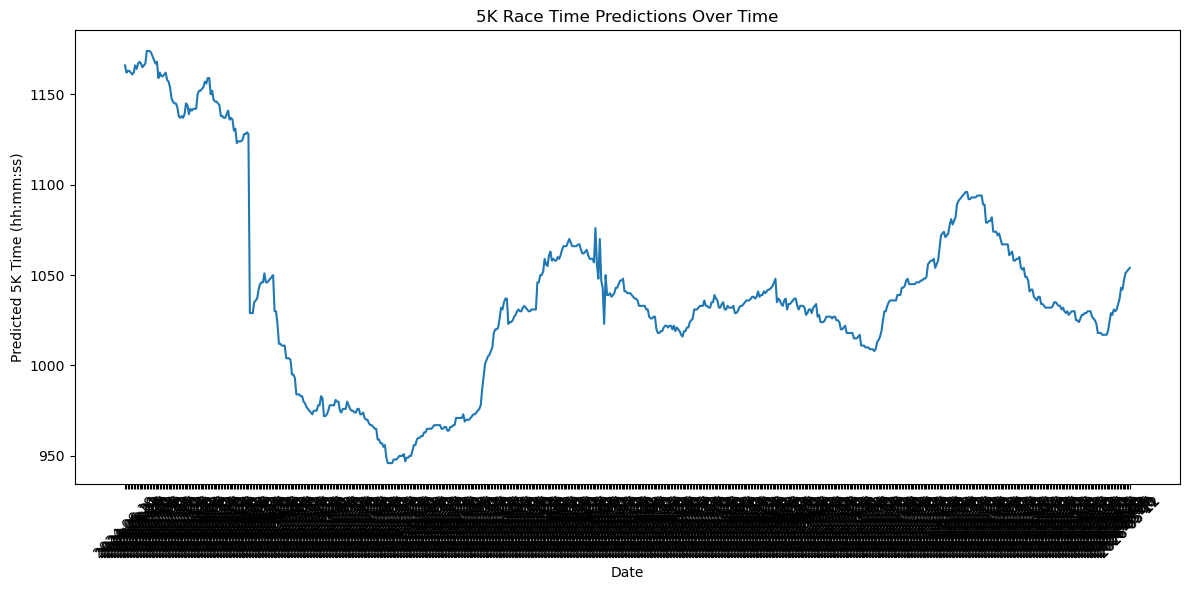

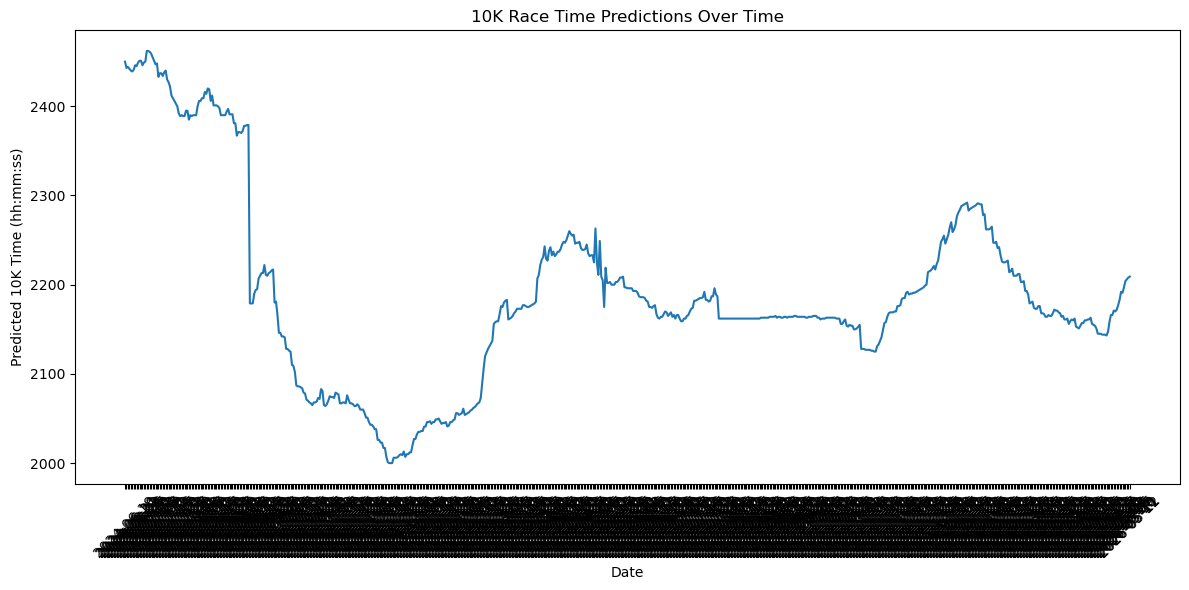

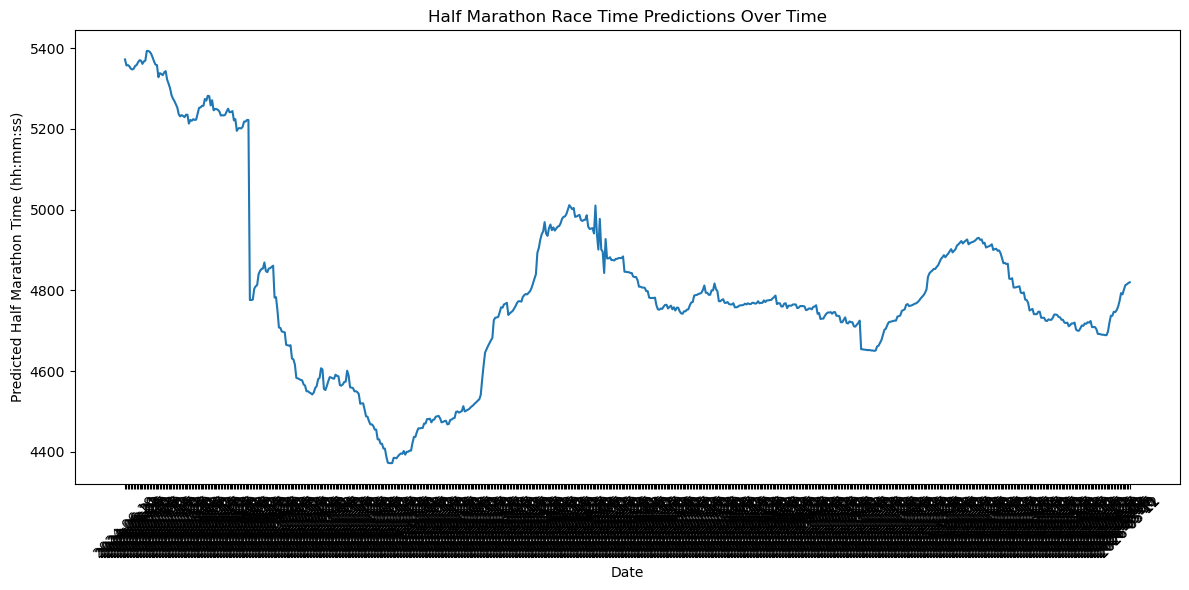

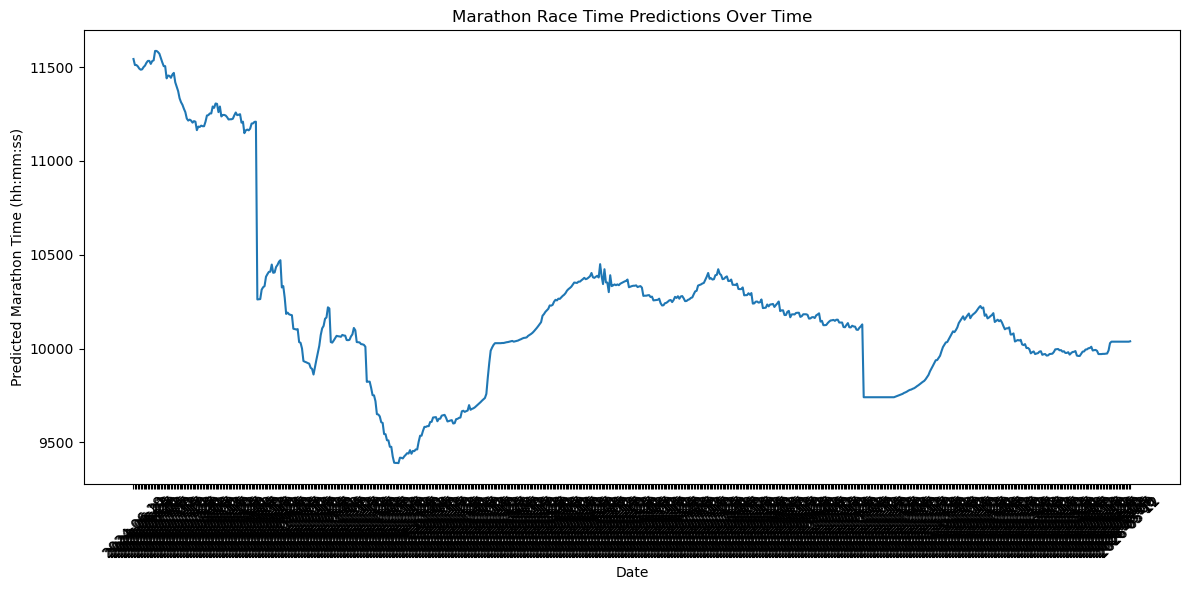

In [7]:
# 5k predictions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=race_predictions_df, x='date', y='raceTime5K')
plt.title('5K Race Time Predictions Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted 5K Time (hh:mm:ss)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10k predictions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=race_predictions_df, x='date', y='raceTime10K')
plt.title('10K Race Time Predictions Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted 10K Time (hh:mm:ss)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Half predictions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=race_predictions_df, x='date', y='raceTimeHalf')
plt.title('Half Marathon Race Time Predictions Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Half Marathon Time (hh:mm:ss)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Marathon predictions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=race_predictions_df, x='date', y='raceTimeMarathon')
plt.title('Marathon Race Time Predictions Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Marathon Time (hh:mm:ss)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Save the cleaned and processed data set to parquet for future use
race_predictions_df.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/race_predicitons_v1.parquet',
    index=False
)